# Intervention Analysis

This notebook analyzes the fact checking intervention experiments for the misinformation-spread project.

It compares three intervention strategies across three network topologies:

- **Random** fact checking nodes
- **High degree** fact checking nodes
- **High betweenness** fact checking nodes

Important note: Some interventions may prevent misinformation from ever reaching 50% of the network. In those cases, `t50` is missing (`NaN`). This is not a mistake; it means the intervention was strong enough that the outbreak did not reach the 50% threshold. Because of this, the notebook uses **AUC**, **final outbreak size**, and **fraction of trials reaching 50% infection** as the main intervention metrics.

In [28]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

# Display settings
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

In [29]:
results_path = DATA_DIR / "intervention_results.csv"
results = pd.read_csv(results_path)

print("Rows:", len(results))
print("Columns:", list(results.columns))
results.head()

Rows: 3000
Columns: ['topology', 'strategy', 'fraction', 'trial', 'n', 'beta', 'gamma', 't10', 't50', 'peak_infected', 'auc', 'final_size', 'duration']


,topology,strategy,fraction,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration
0,ER,none,0.0,0,1000,0.15,0.05,6,10.0,706,19207.5,0.986,153
1,ER,none,0.0,1,1000,0.15,0.05,5,9.0,725,20140.5,0.987,167
2,ER,none,0.0,2,1000,0.15,0.05,5,9.0,746,20514.5,0.994,140
3,ER,none,0.0,3,1000,0.15,0.05,7,11.0,711,19102.5,0.991,136
4,ER,none,0.0,4,1000,0.15,0.05,6,10.0,720,19185.5,0.991,162


We check whether any columns contain missing values. Missing `t50` values are expected when misinformation never reaches 50% infection.

In [30]:
results.isna().sum()

topology           0
strategy           0
fraction           0
trial              0
n                  0
beta               0
gamma              0
t10                0
t50              434
peak_infected      0
auc                0
final_size         0
duration           0
dtype: int64

In [31]:
# Fraction of trials where t50 is missing for each condition
missing_t50_table = (
    results
    .groupby(["topology", "strategy", "fraction"])["t50"]
    .apply(lambda x: x.isna().mean())
    .reset_index(name="missing_t50_fraction")
)

missing_t50_table

,topology,strategy,fraction,missing_t50_fraction
0,BA,betweenness,0.01,0.00
1,BA,betweenness,0.05,0.07
2,BA,betweenness,0.10,1.00
3,BA,degree,0.01,0.00
4,BA,degree,0.05,0.08
5,BA,degree,0.10,1.00
6,BA,none,0.00,0.00
7,BA,random,0.01,0.00
8,BA,random,0.05,0.00
9,BA,random,0.10,0.00


`t50` measures the time needed to reach 50% active infection. However, if a trial never reaches that threshold, `t50` is missing. To capture this directly, we create a new Boolean metric:

- `reached_50 = True` if the trial reached 50% infection
- `reached_50 = False` if it never reached 50% infection

For intervention experiments, a lower `reached_50` rate means the intervention is more effective.

In [32]:
results["reached_50"] = results["t50"].notna()

reached_table = (
    results
    .groupby(["topology", "strategy", "fraction"])["reached_50"]
    .mean()
    .reset_index()
)

reached_table

,topology,strategy,fraction,reached_50
0,BA,betweenness,0.01,1.00
1,BA,betweenness,0.05,0.93
2,BA,betweenness,0.10,0.00
3,BA,degree,0.01,1.00
4,BA,degree,0.05,0.92
5,BA,degree,0.10,0.00
6,BA,none,0.00,1.00
7,BA,random,0.01,1.00
8,BA,random,0.05,1.00
9,BA,random,0.10,1.00


Interpretation:

- Higher `t50` = slower misinformation spread, but only among trials that reached 50% infection
- Lower `final_size` = fewer total nodes ever infected
- Lower `auc` = lower total misinformation burden over time
- Lower `reached_50` = fewer outbreaks reached 50% infection

In [33]:
summary = (
    results
    .groupby(["topology", "strategy", "fraction"])[["t50", "peak_infected", "final_size", "auc", "reached_50"]]
    .agg(["mean", "std"])
)

summary

t50           peak_infected             \
                                    mean       std          mean        std   
topology strategy    fraction                                                 
BA       betweenness 0.01      10.910000  1.272038        677.72  17.091010   
                     0.05      19.612903  2.591928        537.45  21.350076   
                     0.10            NaN       NaN        387.78  25.799765   
         degree      0.01      10.820000  1.217548        679.21  16.720697   
                     0.05      19.706522  2.078345        531.02  21.303473   
                     0.10            NaN       NaN        369.49  27.939869   
         none        0.00       7.900000  1.000000        738.21  15.577305   
         random      0.01       8.000000  1.005038        726.82  14.642114   
                     0.05       8.480000  1.058682        685.50  18.443197   
                     0.10       8.960000  0.941952        636.15  16.405453   
ER       betweenness 0.01      10.850000  1.048086        713.67  16.439700   
                     0.05      12.490000  1.218502        655.82  16.019798   
                     0.10      15.280000  1.436044        588.14  17.019312   
         degree      0.01      10.830000  0.932630        713.23  17.421022   
                     0.05      12.570000  1.066051        655.42  16.603018   
                     0.10      15.420000  1.342243        587.20  16.238127   
         none        0.00      10.410000  0.888706        728.26  15.224661   
         random      0.01      10.390000  0.886430        719.97  18.237743   
                     0.05      10.990000  0.948098        679.26  15.212714   
                     0.10      12.020000  1.136893        629.87  13.888194   
WS       betweenness 0.01      19.000000  1.595448        618.77  20.950570   
                     0.05      23.423913  2.409841        542.45  25.823556   
                     0.10      25.250000  2.217356        453.70  29.871611   
         degree      0.01      18.900000  1.941050        620.17  24.618731   
                     0.05      22.625000  2.318121        546.48  24.042673   
                     0.10      27.400000  2.509980        446.26  27.908805   
         none        0.00      17.760000  1.511705        639.02  21.357931   
         random      0.01      17.850000  1.684001        630.05  19.493265   
                     0.05      19.880000  1.659256        589.57  21.477381   
                     0.10      22.285714  2.417663        528.39  26.246653   

                              final_size                 auc              \
                                    mean       std      mean         std   
topology strategy    fraction                                              
BA       betweenness 0.01        0.97416  0.004505  19404.45  640.014763   
                     0.05        0.89182  0.009713  17798.83  724.906808   
                     0.10        0.77102  0.018141  15485.26  709.155695   
         degree      0.01        0.97450  0.004416  19413.86  649.113670   
                     0.05        0.88738  0.010834  17657.20  738.406536   
                     0.10        0.75730  0.018853  15190.88  787.032013   
         none        0.00        0.99501  0.002699  19825.07  676.544970   
         random      0.01        0.98451  0.002376  19610.31  666.467162   
                     0.05        0.94166  0.003983  18787.33  549.044883   
                     0.10        0.88809  0.004248  17729.71  569.368413   
ER       betweenness 0.01        0.97906  0.003296  19614.06  620.398004   
                     0.05        0.93484  0.004412  18728.96  518.576576   
                     0.10        0.87646  0.005102  17552.30  600.904487   
         degree      0.01        0.97922  0.003404  19593.02  577.706813   
                     0.05        0.93495  0.003976  18727.03  502.087369   
                     0.10        0.87688  0.004981  17576.63 

We first compare strategies at 5% coverage, which is a useful middle intervention level.

In [34]:
fraction_5 = results[results["fraction"] == 0.05].copy()
fraction_5.head()

,topology,strategy,fraction,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration,reached_50
200,ER,random,0.05,0,1000,0.15,0.05,6,10.0,674,18231.5,0.936,222,True
201,ER,random,0.05,1,1000,0.15,0.05,8,12.0,695,19766.5,0.938,178,True
202,ER,random,0.05,2,1000,0.15,0.05,7,12.0,677,19243.5,0.935,198,True
203,ER,random,0.05,3,1000,0.15,0.05,5,10.0,652,18546.5,0.941,123,True
204,ER,random,0.05,4,1000,0.15,0.05,6,10.0,668,18672.5,0.941,138,True


### Figure 1: Time to 50% infection at 5% coverage

Higher values mean slower spread. Missing `t50` values are ignored by the mean, so this plot should be interpreted together with the reached-50% plot below.

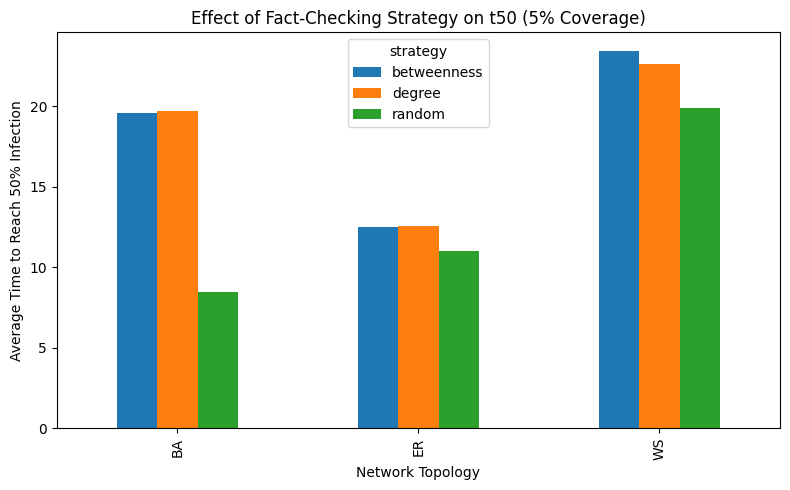

strategy,betweenness,degree,random
topology,,,
BA,19.612903,19.706522,8.48
ER,12.490000,12.570000,10.99
WS,23.423913,22.625000,19.88


In [35]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["t50"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Average Time to Reach 50% Infection")
ax.set_xlabel("Network Topology")
ax.set_title("Effect of Fact-Checking Strategy on t50 (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_t50_5percent.png", dpi=300)
plt.show()

plot_data

### Figure 2: Fraction of trials reaching 50% infection at 5% coverage

Lower values mean better intervention performance.

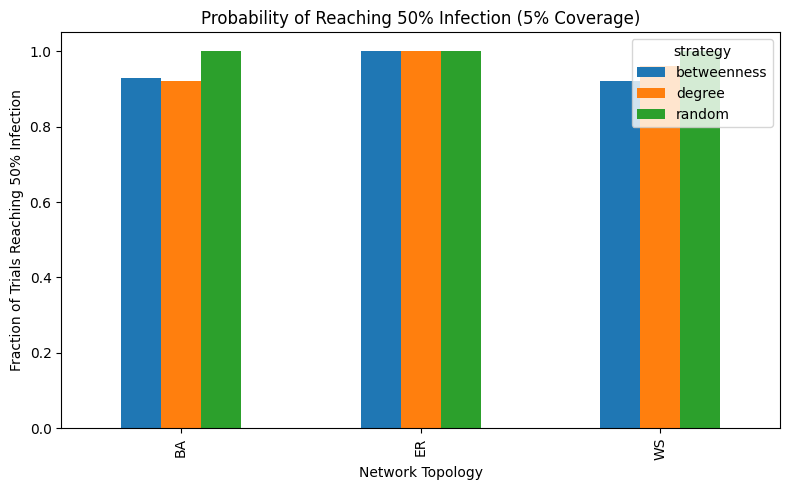

strategy,betweenness,degree,random
topology,,,
BA,0.93,0.92,1.0
ER,1.00,1.00,1.0
WS,0.92,0.96,1.0


In [36]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["reached_50"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Fraction of Trials Reaching 50% Infection")
ax.set_xlabel("Network Topology")
ax.set_title("Probability of Reaching 50% Infection (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_reached50_5percent.png", dpi=300)
plt.show()

plot_data

### Figure 3: Final outbreak size at 5% coverage

Lower values mean fewer total nodes were ever infected.

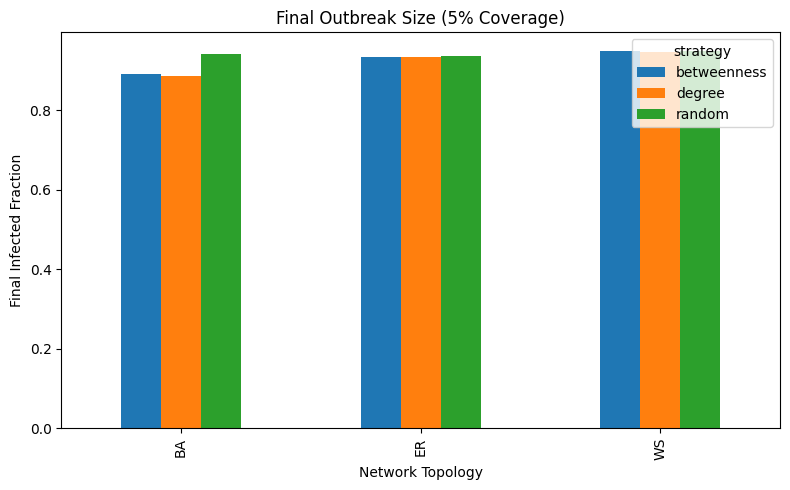

strategy,betweenness,degree,random
topology,,,
BA,0.89182,0.88738,0.94166
ER,0.93484,0.93495,0.93826
WS,0.94882,0.94689,0.94928


In [37]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["final_size"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Final Infected Fraction")
ax.set_xlabel("Network Topology")
ax.set_title("Final Outbreak Size (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_final_size_5percent.png", dpi=300)
plt.show()

plot_data

### Figure 4: Total misinformation burden at 5% coverage

AUC is the area under the active-infection curve. Lower AUC means lower total misinformation burden over time.

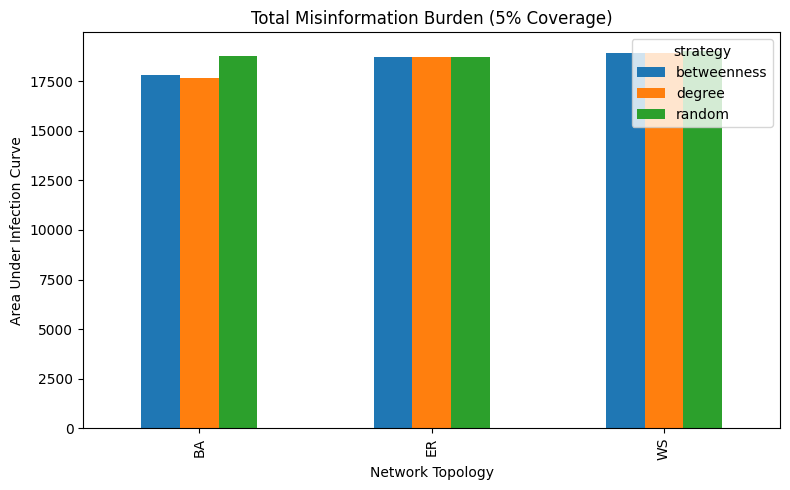

strategy,betweenness,degree,random
topology,,,
BA,17798.83,17657.20,18787.33
ER,18728.96,18727.03,18729.17
WS,18948.30,18936.43,19019.43


In [38]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["auc"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Area Under Infection Curve")
ax.set_xlabel("Network Topology")
ax.set_title("Total Misinformation Burden (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_auc_5percent.png", dpi=300)
plt.show()

plot_data

These plots show how intervention performance changes as fact-checking coverage increases from 1% to 5% to 10%.

Because `none` only exists at fraction 0, we remove it from these coverage plots.

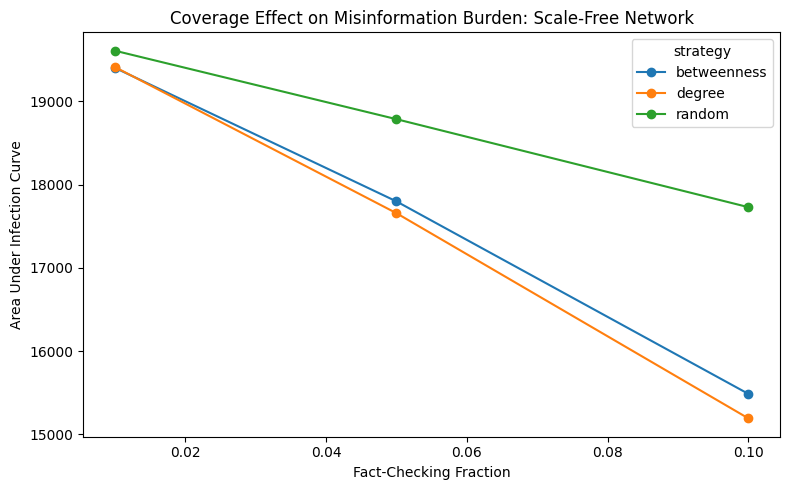

strategy,betweenness,degree,random
fraction,,,
0.01,19404.45,19413.86,19610.31
0.05,17798.83,17657.20,18787.33
0.10,15485.26,15190.88,17729.71


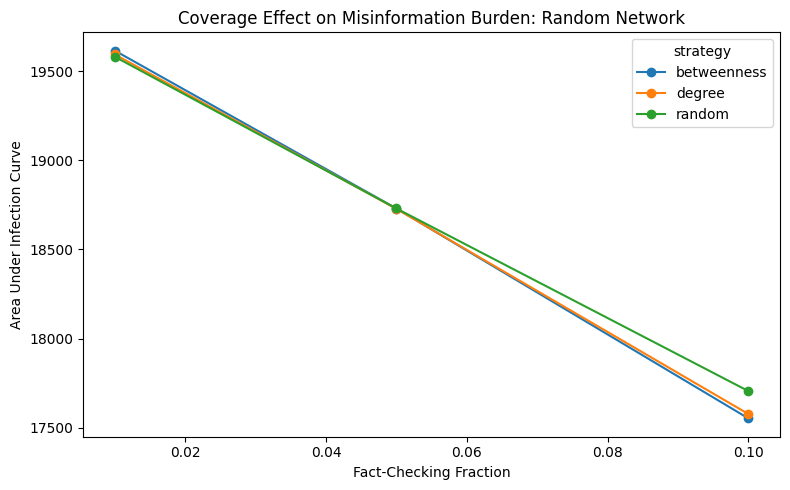

strategy,betweenness,degree,random
fraction,,,
0.01,19614.06,19593.02,19579.84
0.05,18728.96,18727.03,18729.17
0.10,17552.30,17576.63,17705.33


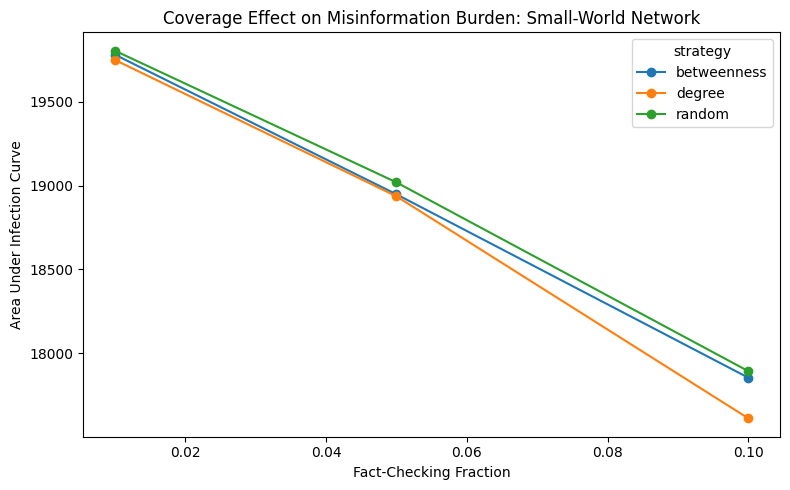

strategy,betweenness,degree,random
fraction,,,
0.01,19781.48,19750.15,19805.14
0.05,18948.30,18936.43,19019.43
0.10,17854.01,17611.50,17893.03


In [39]:
intervention_only = results[results["strategy"] != "none"].copy()

for topology, title in {
    "BA": "Scale-Free Network",
    "ER": "Random Network",
    "WS": "Small-World Network"
}.items():
    subset = intervention_only[intervention_only["topology"] == topology]
    
    plot_data = (
        subset
        .groupby(["fraction", "strategy"])["auc"]
        .mean()
        .unstack()
    )
    
    ax = plot_data.plot(marker="o", figsize=(8, 5))
    ax.set_xlabel("Fact-Checking Fraction")
    ax.set_ylabel("Area Under Infection Curve")
    ax.set_title(f"Coverage Effect on Misinformation Burden: {title}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{topology}_coverage_effect_auc.png", dpi=300)
    plt.show()
    
    display(plot_data)

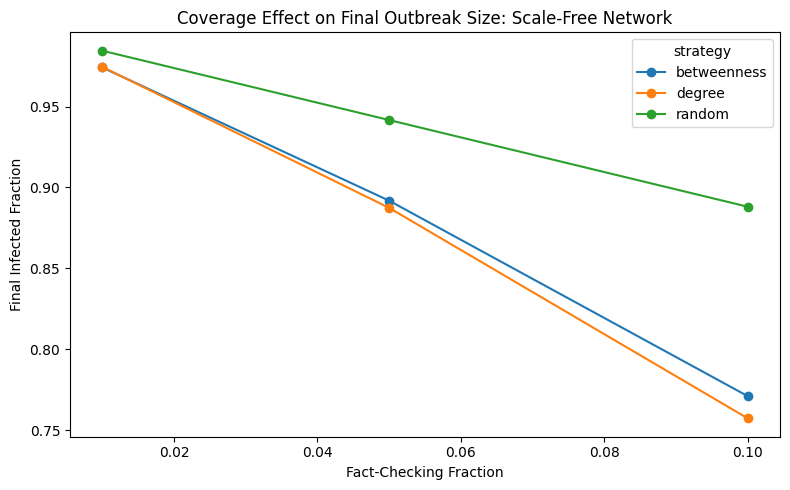

strategy,betweenness,degree,random
fraction,,,
0.01,0.97416,0.97450,0.98451
0.05,0.89182,0.88738,0.94166
0.10,0.77102,0.75730,0.88809


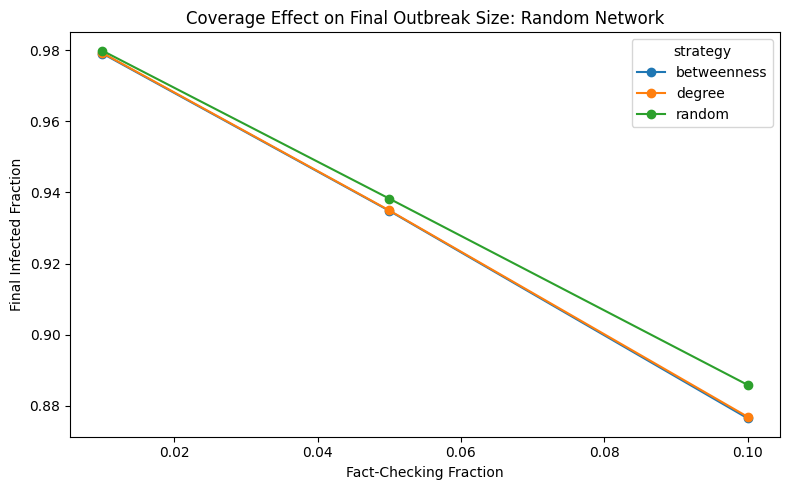

strategy,betweenness,degree,random
fraction,,,
0.01,0.97906,0.97922,0.97985
0.05,0.93484,0.93495,0.93826
0.10,0.87646,0.87688,0.88585


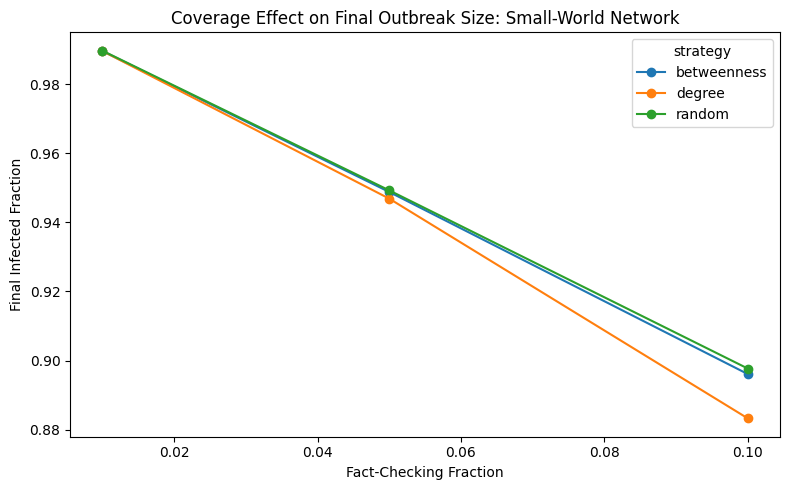

strategy,betweenness,degree,random
fraction,,,
0.01,0.98963,0.98964,0.98973
0.05,0.94882,0.94689,0.94928
0.10,0.89608,0.88325,0.89768


In [40]:
for topology, title in {
    "BA": "Scale-Free Network",
    "ER": "Random Network",
    "WS": "Small-World Network"
}.items():
    subset = intervention_only[intervention_only["topology"] == topology]
    
    plot_data = (
        subset
        .groupby(["fraction", "strategy"])["final_size"]
        .mean()
        .unstack()
    )
    
    ax = plot_data.plot(marker="o", figsize=(8, 5))
    ax.set_xlabel("Fact-Checking Fraction")
    ax.set_ylabel("Final Infected Fraction")
    ax.set_title(f"Coverage Effect on Final Outbreak Size: {title}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{topology}_coverage_effect_final_size.png", dpi=300)
    plt.show()
    
    display(plot_data)

## Identify best strategies

For interventions:

- Best by `auc`: lowest mean AUC
- Best by `final_size`: lowest final infected fraction
- Best by `reached_50`: lowest fraction of trials reaching 50% infection
- Best by `t50`: highest t50 among trials that reached 50%, but this is less reliable when many trials never reach 50%

In [41]:
mean_metrics = (
    results
    .groupby(["topology", "strategy", "fraction"])[["t50", "final_size", "auc", "reached_50"]]
    .mean()
    .reset_index()
)

# Best by AUC for each topology and fraction
best_auc = (
    mean_metrics
    .sort_values(["topology", "fraction", "auc"], ascending=[True, True, True])
    .groupby(["topology", "fraction"])
    .head(1)
)

best_auc

,topology,strategy,fraction,t50,final_size,auc,reached_50
6,BA,none,0.00,7.900000,0.99501,19825.07,1.00
0,BA,betweenness,0.01,10.910000,0.97416,19404.45,1.00
4,BA,degree,0.05,19.706522,0.88738,17657.20,0.92
5,BA,degree,0.10,NaN,0.75730,15190.88,0.00
16,ER,none,0.00,10.410000,0.99041,19844.99,1.00
17,ER,random,0.01,10.390000,0.97985,19579.84,1.00
14,ER,degree,0.05,12.570000,0.93495,18727.03,1.00
12,ER,betweenness,0.10,15.280000,0.87646,17552.30,1.00
26,WS,none,0.00,17.760000,0.99961,19906.70,1.00
23,WS,degree,0.01,18.900000,0.98964,19750.15,1.00


In [42]:
# Best by final outbreak size for each topology and fraction
best_final_size = (
    mean_metrics
    .sort_values(["topology", "fraction", "final_size"], ascending=[True, True, True])
    .groupby(["topology", "fraction"])
    .head(1)
)

best_final_size

,topology,strategy,fraction,t50,final_size,auc,reached_50
6,BA,none,0.00,7.900000,0.99501,19825.07,1.00
0,BA,betweenness,0.01,10.910000,0.97416,19404.45,1.00
4,BA,degree,0.05,19.706522,0.88738,17657.20,0.92
5,BA,degree,0.10,NaN,0.75730,15190.88,0.00
16,ER,none,0.00,10.410000,0.99041,19844.99,1.00
10,ER,betweenness,0.01,10.850000,0.97906,19614.06,1.00
11,ER,betweenness,0.05,12.490000,0.93484,18728.96,1.00
12,ER,betweenness,0.10,15.280000,0.87646,17552.30,1.00
26,WS,none,0.00,17.760000,0.99961,19906.70,1.00
20,WS,betweenness,0.01,19.000000,0.98963,19781.48,1.00


In [43]:
# Best by preventing trials from reaching 50% infection
best_reached_50 = (
    mean_metrics
    .sort_values(["topology", "fraction", "reached_50"], ascending=[True, True, True])
    .groupby(["topology", "fraction"])
    .head(1)
)

best_reached_50

,topology,strategy,fraction,t50,final_size,auc,reached_50
6,BA,none,0.00,7.900000,0.99501,19825.07,1.00
0,BA,betweenness,0.01,10.910000,0.97416,19404.45,1.00
4,BA,degree,0.05,19.706522,0.88738,17657.20,0.92
2,BA,betweenness,0.10,NaN,0.77102,15485.26,0.00
16,ER,none,0.00,10.410000,0.99041,19844.99,1.00
10,ER,betweenness,0.01,10.850000,0.97906,19614.06,1.00
11,ER,betweenness,0.05,12.490000,0.93484,18728.96,1.00
12,ER,betweenness,0.10,15.280000,0.87646,17552.30,1.00
26,WS,none,0.00,17.760000,0.99961,19906.70,1.00
20,WS,betweenness,0.01,19.000000,0.98963,19781.48,1.00


## Statistical tests

### Baseline topology comparison

This ANOVA tests whether baseline spread speed differs across network topologies using the no intervention condition.

In [44]:
baseline = results[results["strategy"] == "none"].copy()

ba_t50 = baseline[baseline["topology"] == "BA"]["t50"].dropna()
er_t50 = baseline[baseline["topology"] == "ER"]["t50"].dropna()
ws_t50 = baseline[baseline["topology"] == "WS"]["t50"].dropna()

f_stat, p_value = f_oneway(ba_t50, er_t50, ws_t50)

print("Baseline topology ANOVA on t50")
print("F-statistic:", f_stat)
print("p-value:", p_value)

Baseline topology ANOVA on t50
F-statistic: 1933.00917135562
p-value: 5.274685185719931e-171


### Intervention strategy comparison within each topology

Because `t50` can be missing when an intervention prevents reaching 50% infection, we use AUC for intervention statistical tests. Lower AUC indicates lower misinformation burden.

In [45]:
for topology in ["BA", "ER", "WS"]:
    subset = results[
        (results["topology"] == topology) &
        (results["fraction"] == 0.05) &
        (results["strategy"] != "none")
    ]
    
    groups = [
        subset[subset["strategy"] == strategy]["auc"].dropna()
        for strategy in ["random", "degree", "betweenness"]
    ]
    
    f_stat, p_value = f_oneway(*groups)
    
    print(f"{topology} intervention ANOVA on AUC at 5% coverage")
    print("F-statistic:", f_stat)
    print("p-value:", p_value)
    print()

BA intervention ANOVA on AUC at 5% coverage
F-statistic: 82.87461815069412
p-value: 2.5147492456745042e-29

ER intervention ANOVA on AUC at 5% coverage
F-statistic: 0.0004653020000283543
p-value: 0.9995348069647947

WS intervention ANOVA on AUC at 5% coverage
F-statistic: 0.4772974700289036
p-value: 0.6209330188882853



### Pairwise Welch t-tests: degree vs random and betweenness vs random

These tests compare each targeted intervention to random fact-checking at 5% coverage using AUC.

In [46]:
pairwise_rows = []

for topology in ["BA", "ER", "WS"]:
    for comparison_strategy in ["degree", "betweenness"]:
        targeted = results[
            (results["topology"] == topology) &
            (results["strategy"] == comparison_strategy) &
            (results["fraction"] == 0.05)
        ]["auc"].dropna()
        
        random_group = results[
            (results["topology"] == topology) &
            (results["strategy"] == "random") &
            (results["fraction"] == 0.05)
        ]["auc"].dropna()
        
        t_stat, p_value = ttest_ind(targeted, random_group, equal_var=False)
        
        pairwise_rows.append({
            "topology": topology,
            "comparison": f"{comparison_strategy} vs random",
            "targeted_mean_auc": targeted.mean(),
            "random_mean_auc": random_group.mean(),
            "t_stat": t_stat,
            "p_value": p_value,
            "targeted_better": targeted.mean() < random_group.mean()
        })

pairwise_results = pd.DataFrame(pairwise_rows)
pairwise_results

,topology,comparison,targeted_mean_auc,random_mean_auc,t_stat,p_value,targeted_better
0,BA,degree vs random,17657.20,18787.33,-12.281885,1.135058e-25,True
1,BA,betweenness vs random,17798.83,18787.33,-10.870252,1.379410e-21,True
2,ER,degree vs random,18727.03,18729.17,-0.027000,9.784878e-01,True
3,ER,betweenness vs random,18728.96,18729.17,-0.002615,9.979164e-01,True
4,WS,degree vs random,18936.43,19019.43,-0.897129,3.707416e-01,True
5,WS,betweenness vs random,18948.30,19019.43,-0.785637,4.330193e-01,True


This section uses `intervention_curves.json`. It plots active misinformation spread over time for no intervention versus selected intervention conditions.

In [47]:
curves_path = DATA_DIR / "intervention_curves.json"

if curves_path.exists():
    with open(curves_path, "r") as f:
        curves = json.load(f)
    
    max_length = max(len(item["infected_counts"]) for item in curves)
    curve_rows = []
    
    for item in curves:
        curve = item["infected_counts"]
        padded_curve = curve + [0] * (max_length - len(curve))
        
        for t, infected in enumerate(padded_curve):
            curve_rows.append({
                "topology": item["topology"],
                "strategy": item["strategy"],
                "fraction": item["fraction"],
                "trial": item["trial"],
                "time": t,
                "infected": infected
            })
    
    curve_df = pd.DataFrame(curve_rows)
    print("Loaded curves:", curve_df.shape)
else:
    curve_df = None
    print("No intervention_curves.json file found.")

Loaded curves: (948000, 6)


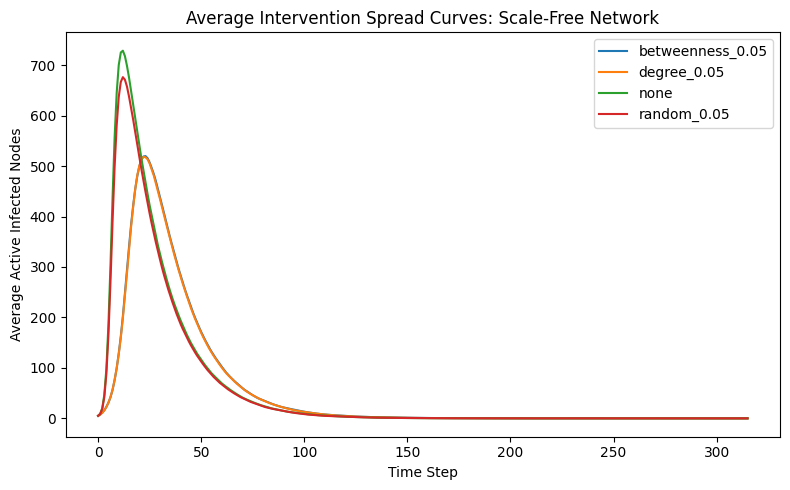

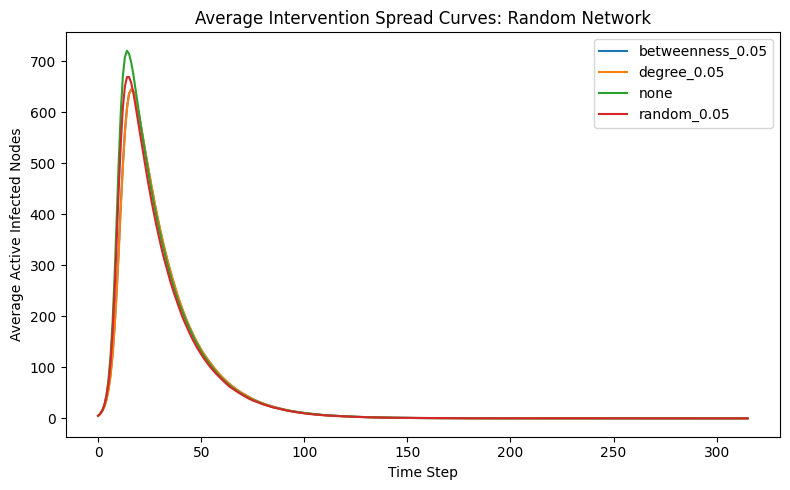

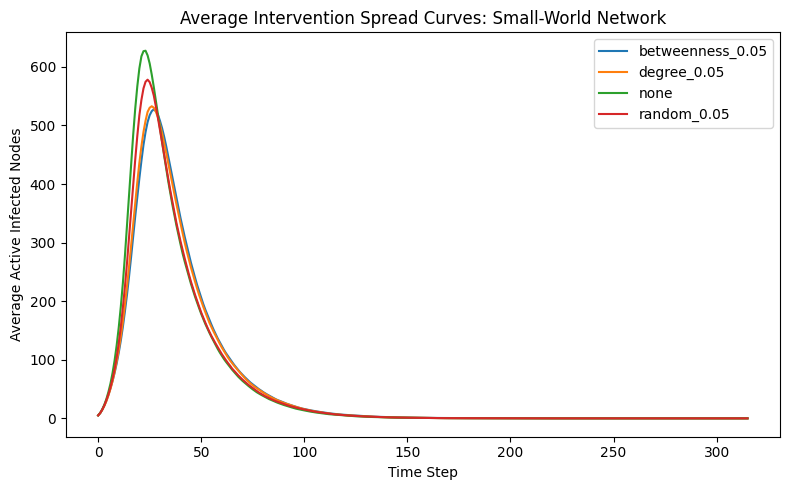

In [48]:
if curve_df is not None:
    selected = curve_df[
        (
            (curve_df["strategy"] == "none") |
            ((curve_df["strategy"] == "degree") & (curve_df["fraction"] == 0.05)) |
            ((curve_df["strategy"] == "betweenness") & (curve_df["fraction"] == 0.05)) |
            ((curve_df["strategy"] == "random") & (curve_df["fraction"] == 0.05))
        )
    ].copy()
    
    selected["condition"] = selected.apply(
        lambda row: "none" if row["strategy"] == "none" else f"{row['strategy']}_{row['fraction']}",
        axis=1
    )
    
    for topology, title in {
        "BA": "Scale-Free Network",
        "ER": "Random Network",
        "WS": "Small-World Network"
    }.items():
        subset = selected[selected["topology"] == topology]
        avg_curve = subset.groupby(["condition", "time"])["infected"].mean().reset_index()
        
        plt.figure(figsize=(8, 5))
        for condition in avg_curve["condition"].unique():
            condition_data = avg_curve[avg_curve["condition"] == condition]
            plt.plot(condition_data["time"], condition_data["infected"], label=condition)
        
        plt.xlabel("Time Step")
        plt.ylabel("Average Active Infected Nodes")
        plt.title(f"Average Intervention Spread Curves: {title}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"{topology}_intervention_average_curves.png", dpi=300)
        plt.show()

# Manuscript revision additions

The original single-comparison plots above are retained as Supporting Online Material. The cells below generate the consolidated manuscript figures, effect sizes, Holm-adjusted p-values, and statistical diagnostics.

**Reproducibility note:** this analysis file records `n`, `beta`, and `gamma`, but it does not contain the graph-generation parameters, exact fact-checker transition rule, or configured step cap. Those details must be added from the simulation-generation code before submission.

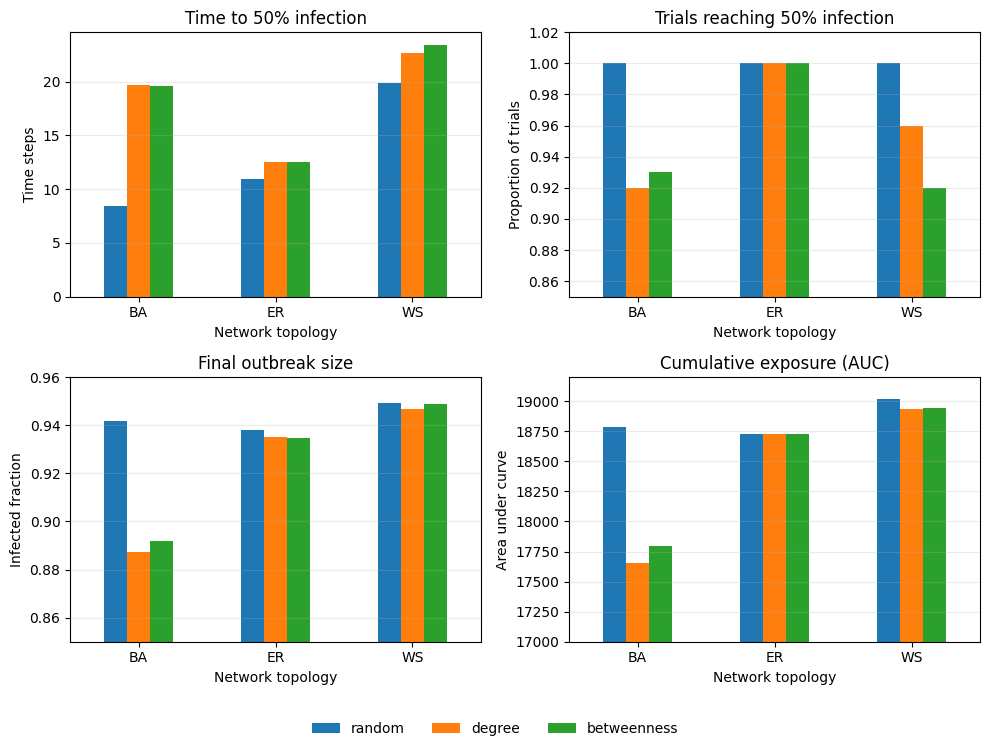

In [49]:
# Core manuscript Figure 3: 5% intervention outcomes in one panel
fraction_5 = results[(results["fraction"] == 0.05) & (results["strategy"] != "none")].copy()
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
specs = [
    ("t50", "Time to 50% infection", "Time steps"),
    ("reached_50", "Trials reaching 50% infection", "Proportion of trials"),
    ("final_size", "Final outbreak size", "Infected fraction"),
    ("auc", "Cumulative exposure (AUC)", "Area under curve"),
]
for ax, (metric, title, ylabel) in zip(axes.ravel(), specs):
    table = fraction_5.groupby(["topology", "strategy"])[metric].mean().unstack().reindex(["BA", "ER", "WS"])[["random", "degree", "betweenness"]]
    table.plot(kind="bar", ax=ax)
    ax.set_title(title); ax.set_xlabel("Network topology"); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0); ax.grid(axis="y", alpha=0.25)
axes[0,1].set_ylim(0.85, 1.02)
axes[1,0].set_ylim(0.85, 0.96)
axes[1,1].set_ylim(17000, 19200)
handles, labels = axes[0,0].get_legend_handles_labels()
for ax in axes.ravel():
    if ax.get_legend() is not None: ax.get_legend().remove()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig(FIGURE_DIR / "intervention_5percent_core.png", dpi=300, bbox_inches="tight")
plt.show()

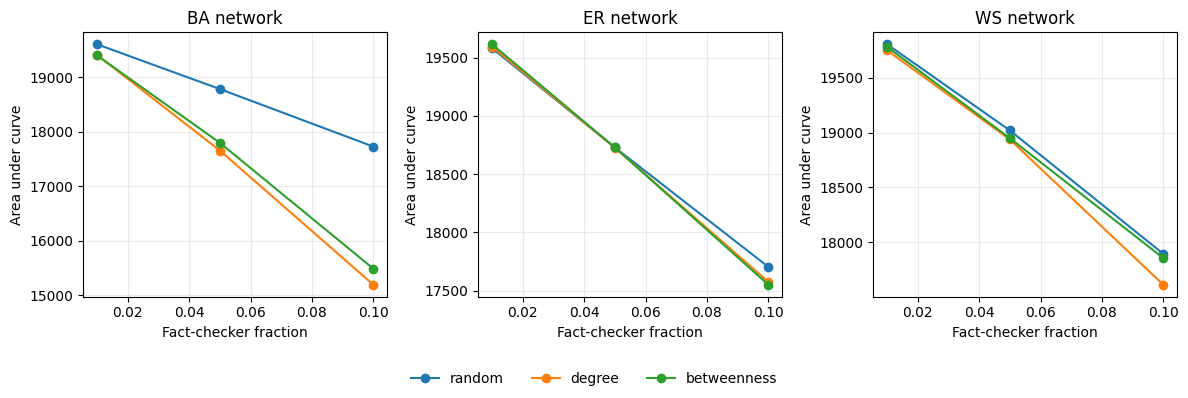

In [50]:
# Core manuscript Figure 4: coverage-response curves for AUC
intervention_only = results[results["strategy"] != "none"].copy()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, top in zip(axes, ["BA", "ER", "WS"]):
    table = intervention_only[intervention_only["topology"] == top].groupby(["fraction", "strategy"])["auc"].mean().unstack()[["random", "degree", "betweenness"]]
    table.plot(marker="o", ax=ax)
    ax.set_title(f"{top} network"); ax.set_xlabel("Fact-checker fraction"); ax.set_ylabel("Area under curve"); ax.grid(alpha=0.25)
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None: ax.get_legend().remove()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.10, 1, 1))
plt.savefig(FIGURE_DIR / "intervention_auc_coverage_core.png", dpi=300, bbox_inches="tight")
plt.show()

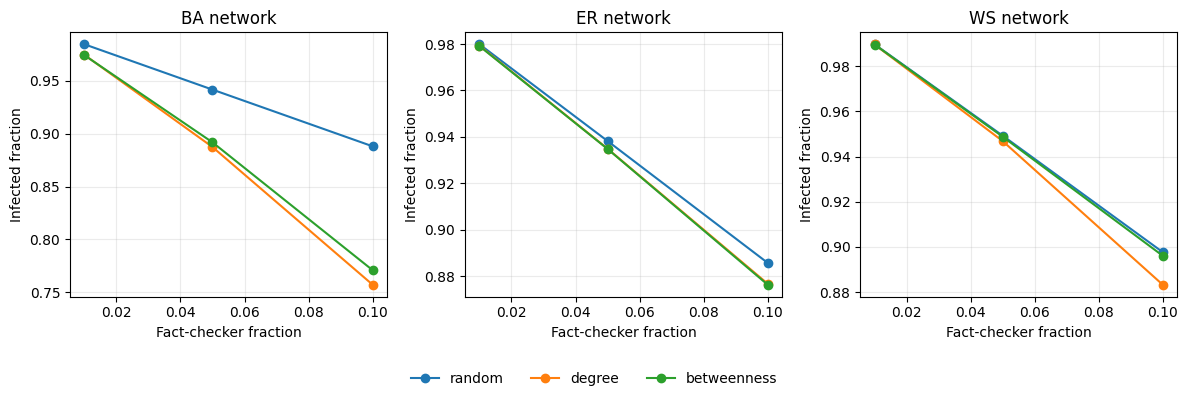

In [51]:
# Core manuscript Figure 5: coverage-response curves for final outbreak size
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, top in zip(axes, ["BA", "ER", "WS"]):
    table = intervention_only[intervention_only["topology"] == top].groupby(["fraction", "strategy"])["final_size"].mean().unstack()[["random", "degree", "betweenness"]]
    table.plot(marker="o", ax=ax)
    ax.set_title(f"{top} network"); ax.set_xlabel("Fact-checker fraction"); ax.set_ylabel("Infected fraction"); ax.grid(alpha=0.25)
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None: ax.get_legend().remove()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.10, 1, 1))
plt.savefig(FIGURE_DIR / "intervention_final_size_coverage_core.png", dpi=300, bbox_inches="tight")
plt.show()

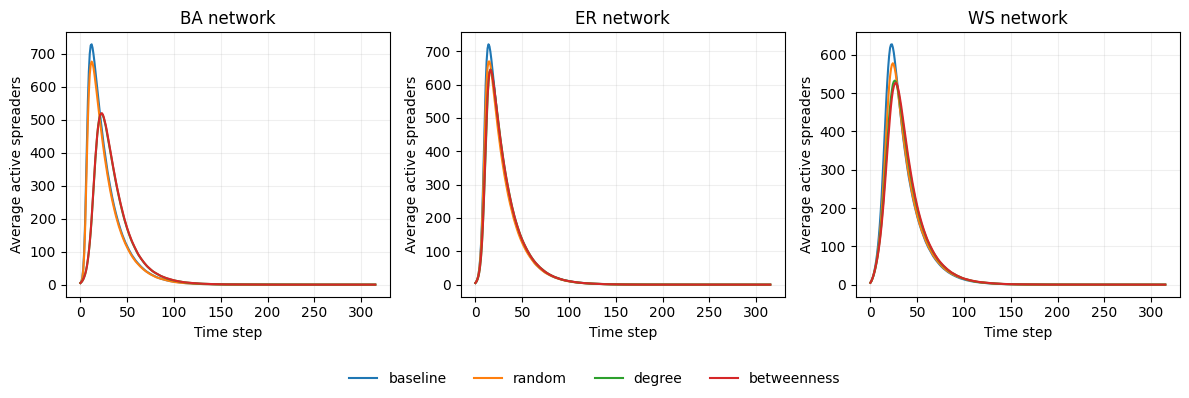

In [52]:
# Core manuscript Figure 6: baseline and 5% intervention curves for all topologies
if curve_df is not None:
    selected = curve_df[(curve_df["strategy"] == "none") | ((curve_df["fraction"] == 0.05) & (curve_df["strategy"].isin(["random", "degree", "betweenness"])))] .copy()
    selected["condition"] = np.where(selected["strategy"] == "none", "baseline", selected["strategy"])
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, top in zip(axes, ["BA", "ER", "WS"]):
        avg = selected[selected["topology"] == top].groupby(["condition", "time"])["infected"].mean().reset_index()
        for condition in ["baseline", "random", "degree", "betweenness"]:
            d = avg[avg["condition"] == condition]
            ax.plot(d["time"], d["infected"], label=condition)
        ax.set_title(f"{top} network"); ax.set_xlabel("Time step"); ax.set_ylabel("Average active spreaders"); ax.grid(alpha=0.2)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)
    fig.tight_layout(rect=(0, 0.10, 1, 1))
    plt.savefig(FIGURE_DIR / "intervention_average_curves_core.png", dpi=300, bbox_inches="tight")
    plt.show()

In [54]:
# Effect sizes and Holm correction for intervention tests
from statsmodels.stats.multitest import multipletests
from scipy.stats import levene, kruskal
from statsmodels.stats.oneway import anova_oneway

anova_rows = []
for top in ["BA", "ER", "WS"]:
    sub = results[(results["topology"] == top) & (results["fraction"] == 0.05) & (results["strategy"] != "none")]
    groups = [sub.loc[sub["strategy"] == s, "auc"].dropna() for s in ["random", "degree", "betweenness"]]
    f_stat, p_value = f_oneway(*groups)
    df_between, df_within = 2, sum(len(g) for g in groups) - 3
    eta_sq = (f_stat * df_between) / (f_stat * df_between + df_within)
    lev_p = levene(*groups, center="median").pvalue
    kw_p = kruskal(*groups).pvalue
    welch_p = anova_oneway(groups, use_var="unequal").pvalue
    anova_rows.append([top, f_stat, p_value, eta_sq, lev_p, kw_p, welch_p])
intervention_anova = pd.DataFrame(anova_rows, columns=["Topology", "F", "p", "eta_squared", "Levene_p", "Kruskal_p", "Welch_ANOVA_p"])
intervention_anova["Holm_p"] = multipletests(intervention_anova["p"], method="holm")[1]

pairwise = pairwise_results.copy()
pairwise["cohens_d"] = pairwise["t_stat"] * np.sqrt(1/100 + 1/100)
pairwise["Holm_p"] = multipletests(pairwise["p_value"], method="holm")[1]

print(intervention_anova[["Topology", "F", "p", "Holm_p", "eta_squared"]].round(4))
pairwise[["topology", "comparison", "t_stat", "p_value", "Holm_p", "cohens_d"]].round(4)

  Topology        F       p  Holm_p  eta_squared
0       BA  82.8746  0.0000     0.0       0.3582
1       ER   0.0005  0.9995     1.0       0.0000
2       WS   0.4773  0.6209     1.0       0.0032


,topology,comparison,t_stat,p_value,Holm_p,cohens_d
0,BA,degree vs random,-12.2819,0.0000,0.0,-1.7369
1,BA,betweenness vs random,-10.8703,0.0000,0.0,-1.5373
2,ER,degree vs random,-0.0270,0.9785,1.0,-0.0038
3,ER,betweenness vs random,-0.0026,0.9979,1.0,-0.0004
4,WS,degree vs random,-0.8971,0.3707,1.0,-0.1269
5,WS,betweenness vs random,-0.7856,0.4330,1.0,-0.1111
